In [61]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [62]:
import sys

print(sys.version)
print(sys.executable)

3.12.10 (v3.12.10:0cc81280367, Apr  8 2025, 08:46:59) [Clang 13.0.0 (clang-1300.0.29.30)]
/Users/sparshanand/Documents/AI-Customer-Retention-Analytics/.venv/bin/python


In [63]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [64]:
df.shape

(7043, 21)

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [66]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [67]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [68]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [69]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [70]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [71]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

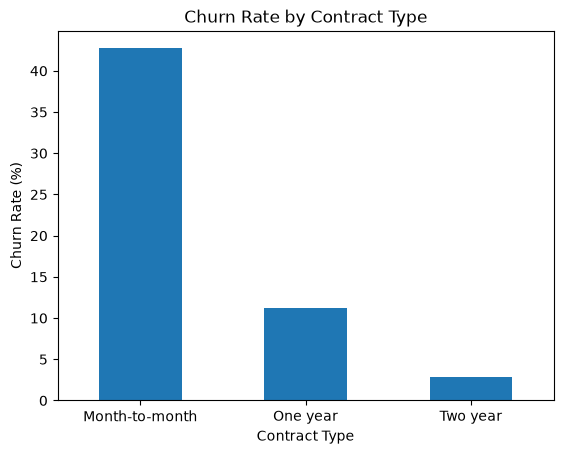

In [72]:
import matplotlib.pyplot as plt

churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)["Yes"] * 100

churn_by_contract.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

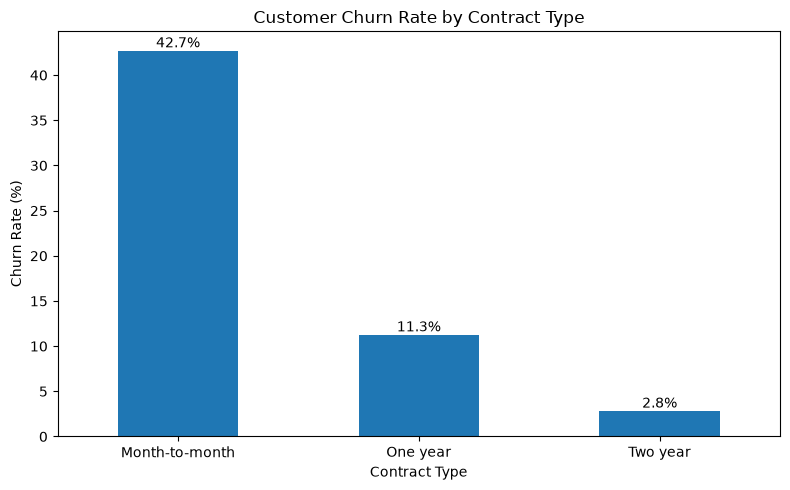

In [73]:
import matplotlib.pyplot as plt

churn_by_contract = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    )["Yes"] * 100
)

ax = churn_by_contract.plot(kind="bar", figsize=(8, 5))

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for bar in ax.patches:
    ax.annotate(
        f"{bar.get_height():.1f}%",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [74]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [75]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [76]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [77]:
pd.crosstab(
    [df["Contract"], df["InternetService"]],
    df["Churn"],
    normalize="index"
)["Yes"].sort_values(ascending=False) * 100

Contract        InternetService
Month-to-month  Fiber optic        54.605263
                DSL                32.215863
One year        Fiber optic        19.294991
Month-to-month  No                 18.893130
One year        DSL                 9.298246
Two year        Fiber optic         7.226107
One year        No                  2.472527
Two year        DSL                 1.910828
                No                  0.783699
Name: Yes, dtype: float64

In [78]:
pd.crosstab(
    [df["Contract"], df["OnlineSecurity"]],
    df["Churn"],
    normalize="index"
)["Yes"].sort_values(ascending=False) * 100

Contract        OnlineSecurity     
Month-to-month  No                     51.045230
                Yes                    29.583333
                No internet service    18.893130
One year        No                     17.414722
                Yes                    10.869565
Two year        No                      6.774194
                Yes                     2.945114
One year        No internet service     2.472527
Two year        No internet service     0.783699
Name: Yes, dtype: float64

In [79]:
pd.crosstab(
    [df["Contract"], df["TechSupport"]],
    df["Churn"],
    normalize="index"
)["Yes"].sort_values(ascending=False) * 100

Contract        TechSupport        
Month-to-month  No                     50.373134
                Yes                    30.700447
                No internet service    18.893130
One year        No                     14.721724
                Yes                    13.586957
Two year        No                      5.932203
                Yes                     3.532278
One year        No internet service     2.472527
Two year        No internet service     0.783699
Name: Yes, dtype: float64

In [80]:
df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean()

,tenure,MonthlyCharges
Churn,,
No,37.569965,61.265124
Yes,17.979133,74.441332


In [81]:
pd.crosstab(
    pd.cut(df["tenure"], bins=[0, 6, 12, 24, 48, 72]),
    df["Churn"],
    normalize="index"
)["Yes"] * 100

tenure
(0, 6]      53.333333
(6, 12]     35.886525
(12, 24]    28.710938
(24, 48]    20.388959
(48, 72]     9.513176
Name: Yes, dtype: float64

In [82]:
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["InternetService"] == "Fiber optic") &
    (df["tenure"] <= 6)
]

high_risk["Churn"].value_counts(normalize=True) * 100

Churn
Yes    74.151858
No     25.848142
Name: proportion, dtype: float64

In [83]:
high_risk.shape

(619, 21)

In [84]:
high_risk[[
    "MonthlyCharges",
    "tenure"
]].describe()


,MonthlyCharges,tenure
count,619.000000,619.000000
mean,80.628110,2.610662
std,9.391515,1.652286
min,67.750000,1.000000
25%,72.875000,1.000000
50%,79.450000,2.000000
75%,86.725000,4.000000
max,109.900000,6.000000


In [85]:
pd.crosstab(
    [high_risk["PaymentMethod"], high_risk["PaperlessBilling"]],
    high_risk["Churn"],
    normalize="index"
) * 100

Churn                                              No         Yes
PaymentMethod             PaperlessBilling                       
Bank transfer (automatic) No                 0.000000  100.000000
                          Yes                9.677419   90.322581
Credit card (automatic)   No                53.846154   46.153846
                          Yes               20.689655   79.310345
Electronic check          No                35.869565   64.130435
                          Yes               21.551724   78.448276
Mailed check              No                36.000000   64.000000
                          Yes               38.028169   61.971831

In [86]:
pd.crosstab(
    high_risk["PaymentMethod"],
    high_risk["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),7.317073,92.682927
Credit card (automatic),30.952381,69.047619
Electronic check,24.545455,75.454545
Mailed check,37.500000,62.500000


In [87]:
# Create a modeling copy
model_df = df.copy()

# Convert TotalCharges from string to numeric
model_df["TotalCharges"] = pd.to_numeric(
    model_df["TotalCharges"], 
    errors="coerce"
)

# Convert target to 0/1
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Check missing values created by conversion
model_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [88]:
# Drop rows with missing TotalCharges
model_df = model_df.dropna(subset=["TotalCharges"])

print("Dataset shape:", model_df.shape)
print("Churn rate:", model_df["Churn"].mean())

Dataset shape: (7032, 21)
Churn rate: 0.26578498293515357


In [89]:
X = model_df.drop(columns=["Churn", "customerID"])
y = model_df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [90]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/35/73dkqcb92b90hfpmc91f24b40000gn/T/ipykernel_4550/1263442432.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ), categorical_features)
    ]
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (5625, 19)
Test set: (1407, 19)


In [92]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8052594171997157
Precision: 0.6515151515151515
Recall: 0.5748663101604278
F1 Score: 0.6107954545454546
ROC-AUC: 0.8360739966143986

Confusion Matrix:
[[918 115]
 [159 215]]


In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [95]:
print("Random Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Results
---------------------
Accuracy: 0.7455579246624022
Precision: 0.5139372822299652
Recall: 0.7887700534759359
F1 Score: 0.6223628691983122
ROC-AUC: 0.8373591274052523

Confusion Matrix:
[[754 279]
 [ 79 295]]


In [96]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance
importances = rf_model.named_steps["model"].feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Display top 15 features
feature_importance.head(15)

,Feature,Importance
1,num__tenure,0.178701
3,num__TotalCharges,0.132536
25,cat__Contract_Two year,0.117894
2,num__MonthlyCharges,0.090310
10,cat__InternetService_Fiber optic,0.072935
28,cat__PaymentMethod_Electronic check,0.058040
24,cat__Contract_One year,0.045468
13,cat__OnlineSecurity_Yes,0.038943
19,cat__TechSupport_Yes,0.024071
18,cat__TechSupport_No internet service,0.019426


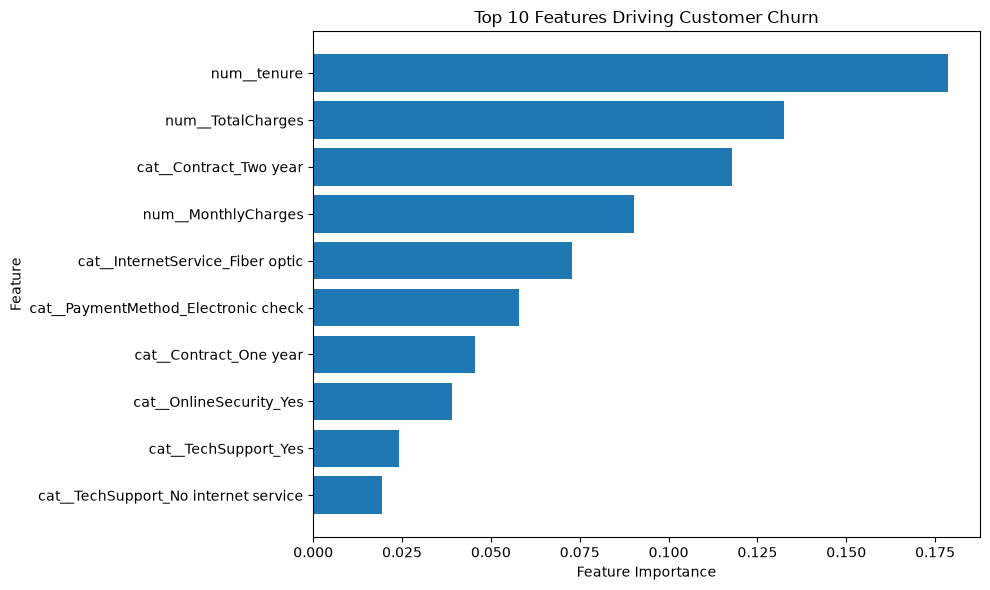

In [97]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top 10 Features Driving Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [98]:
# Create a customer-level risk scoring dataset

risk_df = model_df.loc[X_test.index, [
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "Churn"
]].copy()

# Add predicted churn probability
risk_df["ChurnProbability"] = rf_prob

# Convert probability to percentage
risk_df["ChurnProbabilityPct"] = risk_df["ChurnProbability"] * 100

# Create risk segments
risk_df["RiskSegment"] = pd.cut(
    risk_df["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

# Sort highest-risk customers first
risk_df = risk_df.sort_values(
    "ChurnProbability",
    ascending=False
)

risk_df.head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,Churn,ChurnProbability,ChurnProbabilityPct,RiskSegment
3380,5178-LMXOP,1,95.10,95.10,Month-to-month,Fiber optic,No,No,Electronic check,1,0.941134,94.113384,High Risk
4585,1069-XAIEM,1,85.05,85.05,Month-to-month,Fiber optic,No,No,Electronic check,1,0.940958,94.095776,High Risk
3159,5150-ITWWB,3,94.85,335.75,Month-to-month,Fiber optic,No,No,Electronic check,0,0.937901,93.790078,High Risk
809,1820-TQVEV,1,69.55,69.55,Month-to-month,Fiber optic,No,No,Electronic check,1,0.933942,93.394216,High Risk
3682,3716-BDVDB,1,69.10,69.10,Month-to-month,Fiber optic,No,No,Electronic check,1,0.933563,93.356312,High Risk
3727,9057-SIHCH,3,96.60,291.90,Month-to-month,Fiber optic,No,No,Electronic check,1,0.932115,93.211469,High Risk
1739,9804-ICWBG,1,69.90,69.90,Month-to-month,Fiber optic,No,No,Electronic check,1,0.932084,93.208355,High Risk
2927,5542-TBBWB,1,69.90,69.90,Month-to-month,Fiber optic,No,No,Electronic check,0,0.932084,93.208355,High Risk
1731,8375-DKEBR,1,69.60,69.60,Month-to-month,Fiber optic,No,No,Electronic check,1,0.931841,93.184135,High Risk
2464,2609-IAICY,1,77.15,77.15,Month-to-month,Fiber optic,No,No,Electronic check,1,0.930418,93.041839,High Risk


In [99]:
risk_df["RiskSegment"].value_counts()

RiskSegment
Low Risk       610
High Risk      442
Medium Risk    355
Name: count, dtype: int64

In [100]:
risk_df.groupby("RiskSegment", observed=True)["ChurnProbabilityPct"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
RiskSegment,,,,
Low Risk,610,11.742689,0.174686,29.998201
Medium Risk,355,45.566661,30.021467,59.992949
High Risk,442,76.535328,60.011506,94.113384


In [101]:
# Profile high-risk customers

high_risk_customers = risk_df[
    risk_df["RiskSegment"] == "High Risk"
].copy()

print("High-risk customers:", len(high_risk_customers))

print("\nAverage characteristics:")
print(
    high_risk_customers[
        ["tenure", "MonthlyCharges", "TotalCharges",
         "ChurnProbabilityPct"]
    ].mean()
)

High-risk customers: 442

Average characteristics:
tenure                   11.726244
MonthlyCharges           74.245023
TotalCharges           1006.147851
ChurnProbabilityPct      76.535328
dtype: float64


In [102]:
# High-risk customers by contract type

print("High-risk customers by Contract:")
print(
    pd.crosstab(
        high_risk_customers["Contract"],
        high_risk_customers["Churn"],
        normalize="index"
    ) * 100
)

High-risk customers by Contract:
Churn                   0          1
Contract                            
Month-to-month  41.743119  58.256881
One year        66.666667  33.333333


In [103]:
# High-risk customers by internet service

print("\nHigh-risk customers by Internet Service:")
print(
    pd.crosstab(
        high_risk_customers["InternetService"],
        high_risk_customers["Churn"],
        normalize="index"
    ) * 100
)


High-risk customers by Internet Service:
Churn                    0          1
InternetService                      
DSL              51.063830  48.936170
Fiber optic      38.988095  61.011905
No               58.333333  41.666667


In [104]:
# Top 20 customers requiring retention attention

high_risk_customers[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "PaymentMethod",
        "ChurnProbabilityPct"
    ]
].head(20)

,customerID,tenure,MonthlyCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,ChurnProbabilityPct
3380,5178-LMXOP,1,95.10,Month-to-month,Fiber optic,No,No,Electronic check,94.113384
4585,1069-XAIEM,1,85.05,Month-to-month,Fiber optic,No,No,Electronic check,94.095776
3159,5150-ITWWB,3,94.85,Month-to-month,Fiber optic,No,No,Electronic check,93.790078
809,1820-TQVEV,1,69.55,Month-to-month,Fiber optic,No,No,Electronic check,93.394216
3682,3716-BDVDB,1,69.10,Month-to-month,Fiber optic,No,No,Electronic check,93.356312
3727,9057-SIHCH,3,96.60,Month-to-month,Fiber optic,No,No,Electronic check,93.211469
1739,9804-ICWBG,1,69.90,Month-to-month,Fiber optic,No,No,Electronic check,93.208355
2927,5542-TBBWB,1,69.90,Month-to-month,Fiber optic,No,No,Electronic check,93.208355
1731,8375-DKEBR,1,69.60,Month-to-month,Fiber optic,No,No,Electronic check,93.184135
2464,2609-IAICY,1,77.15,Month-to-month,Fiber optic,No,No,Electronic check,93.041839


In [105]:
# Rank high-risk customers by predicted churn probability

top_20_customers = (
    high_risk_customers
    .sort_values("ChurnProbabilityPct", ascending=False)
    [
        [
            "customerID",
            "tenure",
            "MonthlyCharges",
            "Contract",
            "InternetService",
            "OnlineSecurity",
            "TechSupport",
            "PaymentMethod",
            "ChurnProbabilityPct"
        ]
    ]
    .head(20)
)

top_20_customers

,customerID,tenure,MonthlyCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,ChurnProbabilityPct
3380,5178-LMXOP,1,95.10,Month-to-month,Fiber optic,No,No,Electronic check,94.113384
4585,1069-XAIEM,1,85.05,Month-to-month,Fiber optic,No,No,Electronic check,94.095776
3159,5150-ITWWB,3,94.85,Month-to-month,Fiber optic,No,No,Electronic check,93.790078
809,1820-TQVEV,1,69.55,Month-to-month,Fiber optic,No,No,Electronic check,93.394216
3682,3716-BDVDB,1,69.10,Month-to-month,Fiber optic,No,No,Electronic check,93.356312
3727,9057-SIHCH,3,96.60,Month-to-month,Fiber optic,No,No,Electronic check,93.211469
1739,9804-ICWBG,1,69.90,Month-to-month,Fiber optic,No,No,Electronic check,93.208355
2927,5542-TBBWB,1,69.90,Month-to-month,Fiber optic,No,No,Electronic check,93.208355
1731,8375-DKEBR,1,69.60,Month-to-month,Fiber optic,No,No,Electronic check,93.184135
2464,2609-IAICY,1,77.15,Month-to-month,Fiber optic,No,No,Electronic check,93.041839


In [106]:
# Profile the top 20 highest-risk customers

top_20_customers.describe(include="all")

,customerID,tenure,MonthlyCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,ChurnProbabilityPct
count,20,20.000000,20.000000,20,20,20,20,20,20.000000
unique,20,NaN,NaN,1,1,1,1,2,NaN
top,5178-LMXOP,NaN,NaN,Month-to-month,Fiber optic,No,No,Electronic check,NaN
freq,1,NaN,NaN,20,20,20,20,19,NaN
mean,NaN,1.750000,82.657500,NaN,NaN,NaN,NaN,NaN,92.974959
std,NaN,1.551739,11.890933,NaN,NaN,NaN,NaN,NaN,0.613787
min,NaN,1.000000,69.100000,NaN,NaN,NaN,NaN,NaN,91.910946
25%,NaN,1.000000,69.900000,NaN,NaN,NaN,NaN,NaN,92.442886
50%,NaN,1.000000,81.925000,NaN,NaN,NaN,NaN,NaN,92.972109
75%,NaN,1.500000,94.912500,NaN,NaN,NaN,NaN,NaN,93.247680


In [107]:
# Common characteristics among the top 20 highest-risk customers

for col in [
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod"
]:
    print(f"\n{col}:")
    print(top_20_customers[col].value_counts())


Contract:
Contract
Month-to-month    20
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    20
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No    20
Name: count, dtype: int64

TechSupport:
TechSupport
No    20
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Electronic check    19
Mailed check         1
Name: count, dtype: int64


In [108]:
# Score the entire customer base for retention targeting

all_X = model_df.drop(columns=["Churn", "customerID"])
all_y = model_df["Churn"]

all_prob = rf_model.predict_proba(all_X)[:, 1]

customer_risk = model_df[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "PaymentMethod"
    ]
].copy()

customer_risk["ChurnProbability"] = all_prob
customer_risk["ChurnProbabilityPct"] = all_prob * 100

customer_risk["RiskSegment"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

customer_risk = customer_risk.sort_values(
    "ChurnProbability",
    ascending=False
)

customer_risk.head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,ChurnProbability,ChurnProbabilityPct,RiskSegment
4800,9300-AGZNL,1,94.00,94.00,Month-to-month,Fiber optic,No,No,Electronic check,0.957576,95.757625,High Risk
1976,9497-QCMMS,1,93.55,93.55,Month-to-month,Fiber optic,No,No,Electronic check,0.957462,95.746154,High Risk
3209,8149-RSOUN,1,93.85,93.85,Month-to-month,Fiber optic,No,No,Electronic check,0.949067,94.906657,High Risk
6866,0295-PPHDO,1,95.45,95.45,Month-to-month,Fiber optic,No,No,Electronic check,0.948870,94.886975,High Risk
2577,4910-GMJOT,1,94.60,94.60,Month-to-month,Fiber optic,No,No,Electronic check,0.947734,94.773385,High Risk
1600,3068-OMWZA,1,88.80,88.80,Month-to-month,Fiber optic,No,No,Electronic check,0.946010,94.601026,High Risk
6368,2720-WGKHP,2,94.00,181.70,Month-to-month,Fiber optic,No,No,Electronic check,0.946004,94.600410,High Risk
1410,7024-OHCCK,2,93.85,170.85,Month-to-month,Fiber optic,No,No,Electronic check,0.945204,94.520390,High Risk
6482,5419-JPRRN,1,101.45,101.45,Month-to-month,Fiber optic,No,No,Electronic check,0.944363,94.436272,High Risk
2208,7216-EWTRS,1,100.80,100.80,Month-to-month,Fiber optic,No,No,Electronic check,0.944019,94.401886,High Risk


In [109]:
customer_risk["RiskSegment"].value_counts()

RiskSegment
Low Risk       3149
High Risk      2165
Medium Risk    1718
Name: count, dtype: int64

In [110]:
customer_risk.head(20)[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "Contract",
        "InternetService",
        "OnlineSecurity",
        "TechSupport",
        "PaymentMethod",
        "ChurnProbabilityPct",
        "RiskSegment"
    ]
]

,customerID,tenure,MonthlyCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,ChurnProbabilityPct,RiskSegment
4800,9300-AGZNL,1,94.00,Month-to-month,Fiber optic,No,No,Electronic check,95.757625,High Risk
1976,9497-QCMMS,1,93.55,Month-to-month,Fiber optic,No,No,Electronic check,95.746154,High Risk
3209,8149-RSOUN,1,93.85,Month-to-month,Fiber optic,No,No,Electronic check,94.906657,High Risk
6866,0295-PPHDO,1,95.45,Month-to-month,Fiber optic,No,No,Electronic check,94.886975,High Risk
2577,4910-GMJOT,1,94.60,Month-to-month,Fiber optic,No,No,Electronic check,94.773385,High Risk
1600,3068-OMWZA,1,88.80,Month-to-month,Fiber optic,No,No,Electronic check,94.601026,High Risk
6368,2720-WGKHP,2,94.00,Month-to-month,Fiber optic,No,No,Electronic check,94.600410,High Risk
1410,7024-OHCCK,2,93.85,Month-to-month,Fiber optic,No,No,Electronic check,94.520390,High Risk
6482,5419-JPRRN,1,101.45,Month-to-month,Fiber optic,No,No,Electronic check,94.436272,High Risk
2208,7216-EWTRS,1,100.80,Month-to-month,Fiber optic,No,No,Electronic check,94.401886,High Risk


In [111]:
# Overall customer risk distribution

risk_summary = (
    customer_risk["RiskSegment"]
    .value_counts()
    .rename_axis("RiskSegment")
    .reset_index(name="Customers")
)

risk_summary["Percentage"] = (
    risk_summary["Customers"] / len(customer_risk) * 100
).round(2)

risk_summary

,RiskSegment,Customers,Percentage
0,Low Risk,3149,44.78
1,High Risk,2165,30.79
2,Medium Risk,1718,24.43


In [112]:
# Profile each risk segment

risk_profile = (
    customer_risk
    .groupby("RiskSegment", observed=True)
    .agg(
        Customers=("customerID", "count"),
        Avg_Tenure=("tenure", "mean"),
        Avg_Monthly_Charges=("MonthlyCharges", "mean"),
        Avg_Total_Charges=("TotalCharges", "mean"),
        Avg_Churn_Probability=("ChurnProbabilityPct", "mean")
    )
    .round(2)
)

risk_profile

,Customers,Avg_Tenure,Avg_Monthly_Charges,Avg_Total_Charges,Avg_Churn_Probability
RiskSegment,,,,,
Low Risk,3149,45.91,53.23,2792.99,11.92
Medium Risk,1718,32.53,72.25,2815.16,45.28
High Risk,2165,12.72,75.70,1119.91,76.87


In [113]:
# High-risk customer characteristics

high_risk = customer_risk[
    customer_risk["RiskSegment"] == "High Risk"
]

print("High-risk customers:", len(high_risk))

print("\nContract distribution:")
print(high_risk["Contract"].value_counts(normalize=True).mul(100).round(2))

print("\nInternet service distribution:")
print(high_risk["InternetService"].value_counts(normalize=True).mul(100).round(2))

print("\nPayment method distribution:")
print(high_risk["PaymentMethod"].value_counts(normalize=True).mul(100).round(2))

High-risk customers: 2165

Contract distribution:
Contract
Month-to-month    98.89
One year           1.11
Name: proportion, dtype: float64

Internet service distribution:
InternetService
Fiber optic    76.17
DSL            21.34
No              2.49
Name: proportion, dtype: float64

Payment method distribution:
PaymentMethod
Electronic check             65.54
Mailed check                 16.21
Bank transfer (automatic)     9.33
Credit card (automatic)       8.91
Name: proportion, dtype: float64


In [114]:
0.50

0.5

In [115]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:
    pred = (rf_prob >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print(f"Precision: {precision_score(y_test, pred):.3f}")
    print(f"Recall:    {recall_score(y_test, pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, pred):.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.424
Recall:    0.904
F1 Score:  0.577
------------------------------
Threshold: 0.4
Precision: 0.467
Recall:    0.856
F1 Score:  0.604
------------------------------
Threshold: 0.5
Precision: 0.514
Recall:    0.789
F1 Score:  0.622
------------------------------
Threshold: 0.6
Precision: 0.579
Recall:    0.684
F1 Score:  0.627
------------------------------
Threshold: 0.7
Precision: 0.633
Recall:    0.529
F1 Score:  0.576
------------------------------


In [116]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.805,0.652,0.575,0.611,0.836
1,Random Forest,0.746,0.514,0.789,0.622,0.837


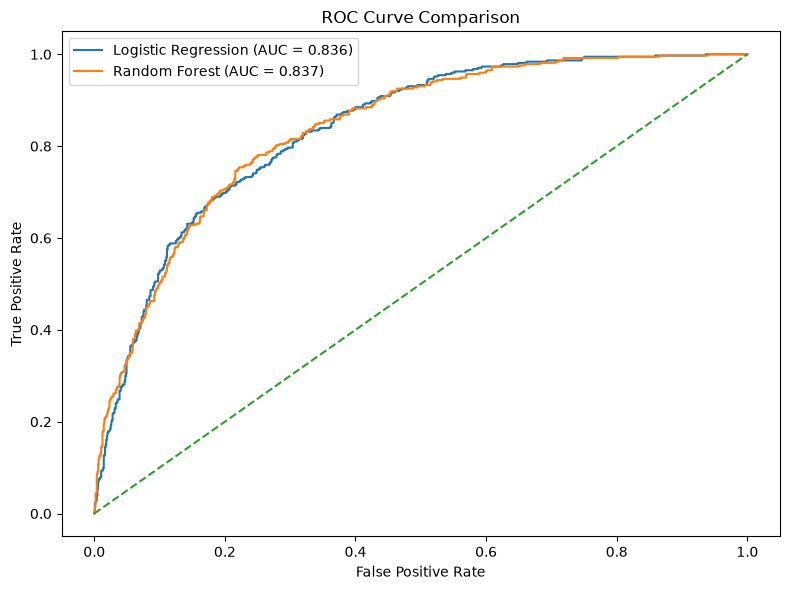

In [117]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr, lr_tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob):.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [118]:
# Refit the final Random Forest on the full dataset

X_all = model_df.drop(columns=["Churn", "customerID"])
y_all = model_df["Churn"]

final_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=4,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

final_rf_model.fit(X_all, y_all)

# Generate final churn probabilities for all customers
all_prob = final_rf_model.predict_proba(X_all)[:, 1]

In [119]:
customer_risk = model_df[[
    "customerID",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Contract",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "Churn"
]].copy()

customer_risk["ChurnProbability"] = all_prob
customer_risk["ChurnProbabilityPct"] = all_prob * 100

In [120]:
customer_risk["RiskSegment"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

In [121]:
customer_risk = customer_risk.sort_values(
    "ChurnProbability",
    ascending=False
)

customer_risk.head(20)


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,Churn,ChurnProbability,ChurnProbabilityPct,RiskSegment
1976,9497-QCMMS,1,93.55,93.55,Month-to-month,Fiber optic,No,No,Electronic check,1,0.955375,95.537503,High Risk
4800,9300-AGZNL,1,94.00,94.00,Month-to-month,Fiber optic,No,No,Electronic check,1,0.955375,95.537503,High Risk
4585,1069-XAIEM,1,85.05,85.05,Month-to-month,Fiber optic,No,No,Electronic check,1,0.952203,95.220279,High Risk
2208,7216-EWTRS,1,100.80,100.80,Month-to-month,Fiber optic,No,No,Electronic check,1,0.949232,94.923151,High Risk
6866,0295-PPHDO,1,95.45,95.45,Month-to-month,Fiber optic,No,No,Electronic check,1,0.948071,94.807088,High Risk
6623,9248-OJYKK,1,76.45,76.45,Month-to-month,Fiber optic,No,No,Electronic check,1,0.946400,94.639988,High Risk
7032,6894-LFHLY,1,75.75,75.75,Month-to-month,Fiber optic,No,No,Electronic check,1,0.946400,94.639988,High Risk
3209,8149-RSOUN,1,93.85,93.85,Month-to-month,Fiber optic,No,No,Electronic check,1,0.945518,94.551811,High Risk
534,9282-IZGQK,1,85.00,85.00,Month-to-month,Fiber optic,No,No,Electronic check,1,0.945212,94.521220,High Risk
2577,4910-GMJOT,1,94.60,94.60,Month-to-month,Fiber optic,No,No,Electronic check,1,0.944724,94.472351,High Risk


In [122]:
high_risk_customers.groupby("OnlineSecurity")["ChurnProbabilityPct"].agg(
    ["count", "mean"]
)

,count,mean
OnlineSecurity,,
No,388,77.834203
No internet service,12,64.444767
Yes,42,67.990643


In [123]:
high_risk_customers.groupby("TechSupport")["ChurnProbabilityPct"].agg(
    ["count", "mean"]
)

,count,mean
TechSupport,,
No,389,77.564309
No internet service,12,64.444767
Yes,41,70.311257


In [124]:
high_risk_customers.groupby("tenure")["ChurnProbabilityPct"].mean()

tenure
1     80.322953
2     81.365904
3     79.128403
4     79.652601
5     76.205343
6     80.188529
7     79.705859
8     84.887158
9     81.202869
10    78.752344
11    79.187328
12    69.855839
13    74.258524
14    79.126830
15    75.240434
16    70.747247
17    71.280384
18    69.342972
19    70.056644
20    67.094747
21    75.814039
22    67.575400
23    74.755279
24    71.181816
25    66.867082
26    75.498996
27    69.499464
28    65.533453
29    77.108817
30    68.556483
31    68.544495
32    67.537104
33    65.668250
34    70.908802
35    70.035407
36    69.523119
37    70.739000
38    65.101524
40    66.216620
42    68.755228
43    60.487099
45    70.205133
47    67.373622
48    61.125276
49    70.132643
50    65.438325
52    60.677192
53    71.284098
54    64.421134
55    62.781445
60    60.336112
66    65.173049
Name: ChurnProbabilityPct, dtype: float64

In [125]:
customer_risk["Priority"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=[
        "Low Priority",
        "Medium Priority",
        "High Priority",
        "Immediate Attention"
    ],
    include_lowest=True
)

In [126]:
customer_risk["Priority"].value_counts()

Priority
Low Priority           3104
Medium Priority        1731
High Priority          1370
Immediate Attention     827
Name: count, dtype: int64

In [127]:
# Business Recommendations
# Finding 1 — Short-tenure customers are important

# Tenure is the most important Random Forest feature at 0.179.
# Historical EDA also shows churn is much higher among customers with 0–6 months of tenure (53.33%) than among customers with 48–72 months (9.51%).
# Recommendation: create an early-tenure onboarding/retention program.

# Finding 2 — Contract type matters

# Month-to-month customers have a substantially higher observed churn rate than one- and two-year customers.
# Recommendation: test incentives for customers to move to longer contracts.

# Finding 3 — High-risk customers are concentrated

# Your full customer scoring identifies 2,165 high-risk customers (30.79%).
# Their average predicted churn probability is 76.87%, versus 45.28% for medium risk and 11.92% for low risk.

# Finding 4 — Fiber optic + electronic check appears frequently in the high-risk group

# 76.17% of high-risk customers use fiber optic.
# 65.54% use electronic check.
# 98.89% are month-to-month.

#Early-tenure onboarding/retention program
#Incentives for longer-term contracts
#Targeted intervention for high-risk customers
#Review payment-method friction / electronic-check customers
#Consider service/support engagement for high-risk customers

In [128]:
# visual for risk segmentation

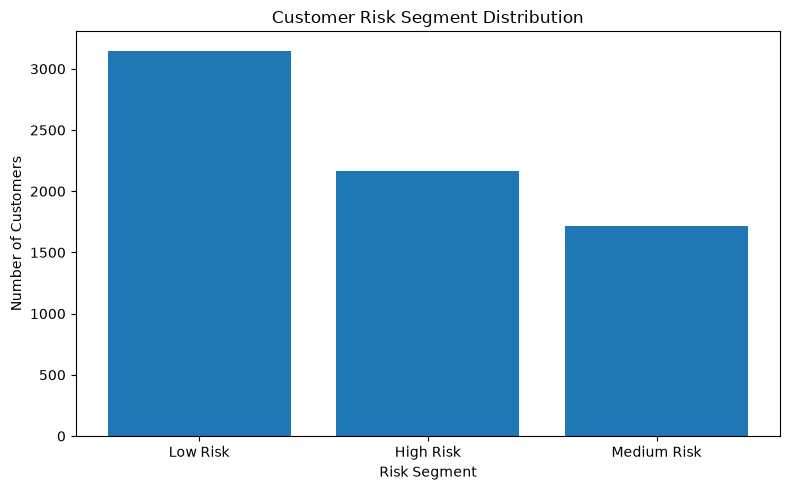

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    risk_summary["RiskSegment"],
    risk_summary["Customers"]
)

plt.title("Customer Risk Segment Distribution")
plt.xlabel("Risk Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [130]:
# visual for the retention strategy

In [131]:
high_risk_profile = pd.DataFrame({
    "Characteristic": [
        "Month-to-month",
        "Fiber optic",
        "Electronic check"
    ],
    "Percentage": [
        (high_risk["Contract"] == "Month-to-month").mean() * 100,
        (high_risk["InternetService"] == "Fiber optic").mean() * 100,
        (high_risk["PaymentMethod"] == "Electronic check").mean() * 100
    ]
})

high_risk_profile

,Characteristic,Percentage
0,Month-to-month,98.891455
1,Fiber optic,76.166282
2,Electronic check,65.542725


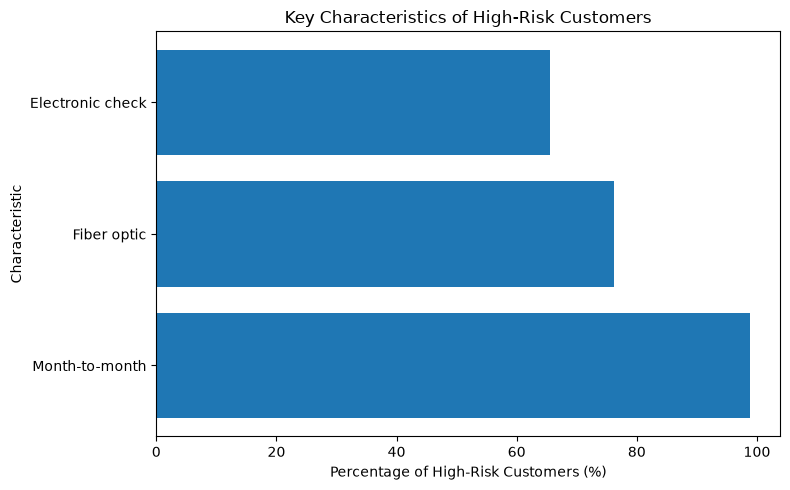

In [132]:
plt.figure(figsize=(8, 5))

plt.barh(
    high_risk_profile["Characteristic"],
    high_risk_profile["Percentage"]
)

plt.title("Key Characteristics of High-Risk Customers")
plt.xlabel("Percentage of High-Risk Customers (%)")
plt.ylabel("Characteristic")

plt.tight_layout()
plt.show()

In [133]:
# Limitations
# Model limitations

# Random Forest has:

#Accuracy: 74.6%
#Precision: 51.4%
#Recall: 78.9%
#F1: 62.2%
#ROC-AUC: 83.7%

#Logistic Regression has:

#Accuracy: 80.5%
#Precision: 65.2%
#Recall: 57.5%
#F1: 61.1%
#ROC-AUC: 83.6%


#Model limitations

#Predictions are based on historical customer behavior.
#The model identifies associations/predictive patterns; it does not establish that a particular factor causes churn.
#Risk probabilities should be validated on future customer data.
#Retention campaigns should be evaluated using actual outcomes/A-B testing.

In [134]:
# Conclusion

#This analysis developed a customer churn prediction and retention-targeting framework using Logistic Regression and Random Forest models. The analysis identified important churn patterns related to tenure, contract type, monthly charges, and customer service characteristics. The final risk-scoring framework segments customers according to predicted churn probability and identifies a high-risk group for targeted retention actions. These results can support a more proactive, data-driven customer retention strategy.